In [30]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from lmfit import Minimizer, Parameters
import seaborn as sns
from rich.progress import track

sns.set(color_codes=True, style="white")

## Load Data

In [31]:
# folder = "/Volumes/lsa-nwalter/Guoming_Gao_turbo/Walterlab_server/PROCESSED_DATA/RNA-in-HOPS_condensates/paper_figure_plots/Effect_traslation_FLmRNA"
folder = "/Volumes/lsa-nwalter/Sam_Husna_turbo/Data/HOPS-RNA-project/paper_figure_plots/Effect_traslation_FLmRNA"

os.chdir(folder)

lst_color = [
    "#398bc3",  # FL, 2x
    "#0077B6",  # FL, 2x, puro
    "#0096c7",  # FL, 2x, Har
    "#00B4D8",  # FL, 2x, CHX
    "#48cae4",  # FL, 2x, 4EGI1
]

lst_title = [
    "translation active",
    "+puromycin",
    "+harringtonine",
    "+cycloheximide",
    "+4EGI1",
]

lst_fname = [
    "FL_2x",
    "FL_puro_2x",
    "FL_Har_2x",
    "FL_CHX_2x",
    "FL_4EGI1_2x",
]

In [32]:
lst_df = [pd.read_csv(f"colocalization_AIO_concat-{f}_100ms.csv") for f in lst_fname]

In [33]:
conditions_label = [
    "translation active",
    "+puro",
    "+har",
    "+chx",
    "+4EGI",
    "translation active",
    "+puro",
    "+har",
    "+chx",
    "+4EGI"
]


## Functions

In [34]:
def get_dwell_times(cond_flag, track_id):
    c_change = np.where(cond_flag[:-1] != cond_flag[1:])[0] + 1
    t_change = np.where(track_id[:-1] != track_id[1:])[0] + 1
    boundaries = np.unique(np.concatenate((c_change, t_change)))
    boundaries = np.concatenate(([0], boundaries, [len(cond_flag)]))
    dwells = []
    for i in range(len(boundaries)-1):
        start = boundaries[i]
        if cond_flag[start]:
            dwells.append(boundaries[i+1] - start)
    return np.array(dwells)


def calc_R2(data, fit):
    resid = data - fit
    ss_res = np.sum(resid**2)
    ss_tot = np.sum((data - data.mean())**2)
    return 1 - ss_res/ss_tot


def cdf_residuals(params, t, cdf):
    a1 = params['a1']
    a2 = 1 - a1
    tau1 = params['tau1']
    tau2 = params['tau2']
    model = 1 - a1*np.exp(-t/tau1) - a2*np.exp(-t/tau2)
    return model - cdf


def fit_dual_exponential(dwells, pct=0.99):
    cutoff = np.quantile(dwells, pct)
    dt = dwells[dwells <= cutoff]
    bins, brange = 100, (0.1, 3)
    hist, edges = np.histogram(dt, bins=bins, range=brange, density=True)
    cdf = np.cumsum(hist)/hist.sum()
    t = edges[:-1] + brange[1]/bins

    params = Parameters()
    params.add('a1',   min=0, max=1,   value=0.5)
    params.add('tau1', min=0.03, max=0.5, value=0.1)
    params.add('tau2', min=0.5,  max=2.0, value=1.0)

    minner = Minimizer(cdf_residuals, params, fcn_args=(t, cdf))
    result = minner.minimize()
    fit_cdf = cdf + result.residual
    R2 = calc_R2(cdf, fit_cdf)

    return {
        't':       t,
        'cdf':     cdf,
        'fitted':  fit_cdf,
        'a1':      result.params['a1'].value,
        'a2':      1 - result.params['a1'].value,
        'tau1':    result.params['tau1'].value,
        'tau2':    result.params['tau2'].value,
        'a1_se':   result.params['a1'].stderr,
        'tau1_se': result.params['tau1'].stderr,
        'tau2_se': result.params['tau2'].stderr,
        'R2':      R2,
    }


def count_dwell_events(cond_flag, track_id):
    c_change = np.where(cond_flag[:-1] != cond_flag[1:])[0] + 1
    t_change = np.where(track_id[:-1] != track_id[1:])[0] + 1
    boundaries = np.unique(np.concatenate((c_change, t_change)))
    boundaries = np.concatenate(([0], boundaries, [len(cond_flag)]))
    t_bounds = np.concatenate(([0], t_change, [len(track_id)]))
    counts = []
    for i in range(len(t_bounds)-1):
        mask = (c_change >= t_bounds[i]) & (c_change <= t_bounds[i+1])
        counts.append(mask.sum())
    return np.array(counts)


def bootstrap_event_fractions(arr, pct=0.3, nboot=1000):
    arr = arr[arr>0]
    n = int(len(arr)*pct)
    f1, f2, f3 = [], [], []
    for _ in range(nboot):
        samp = np.random.choice(arr, size=n, replace=True)
        f1.append((samp==1).sum()/n)
        f2.append(((samp>1)&(samp<=3)).sum()/n)
        f3.append((samp>3).sum()/n)
    def stats(x):
        return np.mean(x), (np.percentile(x,95)-np.percentile(x,5))/2
    return stats(f1) + stats(f2) + stats(f3)

## Interaction (Dwell) Time Calculate

In [35]:
#––– Process Data –––
dwell_data = []
fit_results = {}
for df, key in zip(lst_df, lst_fname):
    raw = get_dwell_times(df['InCondensate'].to_numpy(),
                          df['RNA_trackID'].to_numpy()) * 0.1
    dwell_data.append(raw)
    fit_results[key] = fit_dual_exponential(raw, pct=0.99)

## Fit to CDF, 1x, 2x, individually, no split

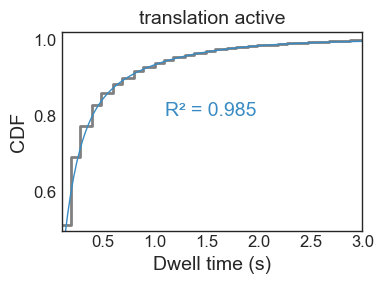

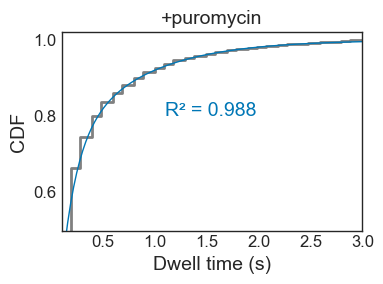

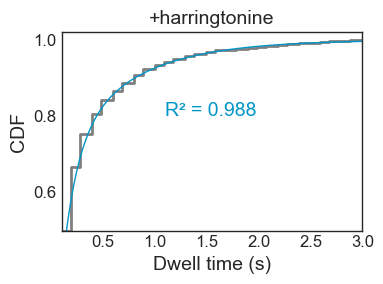

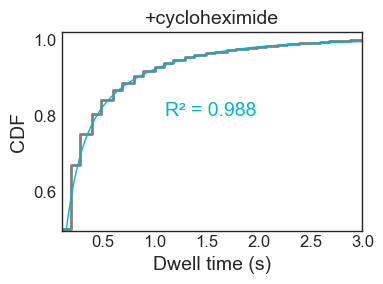

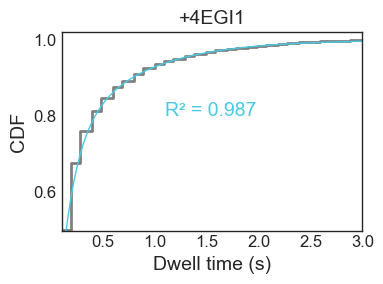

In [36]:
#––– Plot CDF + Dual‐Exp Fit –––

for dt, key, col, title in zip(dwell_data, lst_fname, lst_color, lst_title):
    res = fit_results[key]
    plt.figure(figsize=(4,3))
    sns.histplot(dt, bins=100, binrange=(0.1,3),
                 stat='probability', cumulative=True,
                 element='step', fill=False, color='gray', lw=2)
    plt.plot(res['t'], res['fitted'],
             color=col, lw=1, label='2-exp fit')
    plt.text(1.1, 0.8, f"R² = {res['R2']:.3f}",
             fontsize=14, color=col)
    plt.xlabel("Dwell time (s)", fontsize=14)
    plt.ylabel("CDF", fontsize=14)
    plt.title(title, fontsize=14)
    plt.xlim(0.1,3); plt.ylim(0.5,1.02)
    ax = plt.gca()
    ax.spines[:].set_linewidth(1)
    ax.tick_params(labelsize=12, direction='in', length=5, width=1)
    plt.tight_layout()
    plt.savefig(f"compare_dualexp_{key}.svg", dpi=300, bbox_inches='tight', format='svg')
    plt.show()

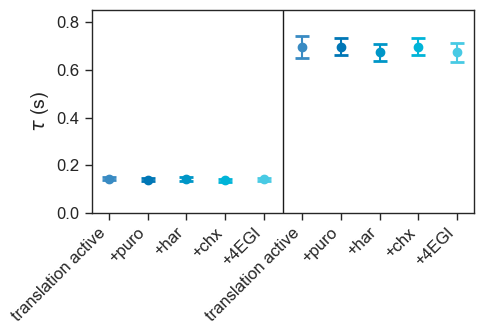

In [37]:
#––– τ Errorbar Plot –––

conds = lst_fname
n = len(conds)
tau_fast = np.array([fit_results[c]['tau1']    for c in conds])
tau_fast_se = np.array([fit_results[c]['tau1_se'] for c in conds])
tau_slow = np.array([fit_results[c]['tau2']    for c in conds])
tau_slow_se = np.array([fit_results[c]['tau2_se'] for c in conds])
labels_full = [f"{t}, 2-exp [fast]" for t in lst_title] + \
              [f"{t}, 2-exp [slow]" for t in lst_title]
colors_full = lst_color*2
lst_tau = np.concatenate([tau_fast, tau_slow])
lst_tau_se = np.concatenate([tau_fast_se, tau_slow_se])

plt.figure(figsize=(5, 3.5))
x = np.arange(len(labels_full))
plt.axvline((x[n-1]+x[n])/2, c='k', lw=1)
for i in range(len(x)):
    plt.errorbar(x[i], lst_tau[i], yerr=lst_tau_se[i],
                 fmt='o', capsize=5, capthick=2, color=colors_full[i])
plt.xticks(x, conditions_label, rotation=45, ha='right', fontsize=12)
plt.ylim(0, 0.85)
plt.ylabel(r"$\tau$ (s)", fontsize=14)
plt.gca().spines[:].set_linewidth(1)
plt.gca().tick_params(axis='both', which='major', labelsize=12,
                      direction='out', length=5, width=1, bottom=True, left=True)
plt.tight_layout()
plt.savefig("doterrorplot_tau_dual.svg", dpi=300, bbox_inches='tight', format='svg')
plt.show()

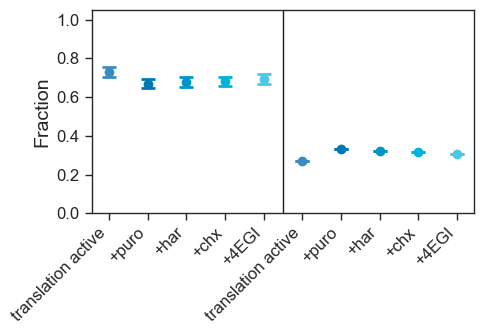

In [38]:
#––– Fraction Errorbar Plot –––
frac_fast = np.array([fit_results[c]['a1']   for c in conds])
frac_fast_se = np.array([fit_results[c]['a1_se'] for c in conds])
frac_slow = np.array([fit_results[c]['a2']   for c in conds])
frac_slow_se = np.array([fit_results[c]['a1_se']*0 for c in conds])  # no separate stderr for a2
labels_frac = [f"{t}, 2-exp [fast]" for t in lst_title] + \
              [f"{t}, 2-exp [slow]" for t in lst_title]
lst_frac = np.concatenate([frac_fast, frac_slow])
lst_frac_se = np.concatenate([frac_fast_se, frac_slow_se])

plt.figure(figsize=(5,3.5))
x = np.arange(len(labels_frac))
plt.axvline((x[n-1]+x[n])/2, c='k', lw=1)
for i in range(len(x)):
    plt.errorbar(x[i], lst_frac[i], yerr=lst_frac_se[i],
                 fmt='o', capsize=5, capthick=2, color=colors_full[i])
plt.xticks(x, conditions_label, rotation=45, ha='right', fontsize=12)
plt.ylim(0, 1.05)
plt.ylabel("Fraction", fontsize=14)
plt.gca().spines[:].set_linewidth(1)
plt.gca().tick_params(axis='both', which='major', labelsize=12,
                      direction='out', length=5, width=1, bottom=True, left=True)
plt.tight_layout()
plt.savefig("doterrorplot_frac_dual.svg", dpi=300, bbox_inches='tight', format='svg')
plt.show()